In [4]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage import feature, io, color

In [5]:
# 1. Chuẩn bị ảnh
# Đọc ảnh bằng OpenCV (chuyển sang mức xám) [cite: 787]
img_cv = cv2.imread('anh4.jpg', cv2.IMREAD_GRAYSCALE)

In [6]:
# Đọc ảnh bằng Scikit-image (chuyển sang mức xám) [cite: 788]
img_sk = color.rgb2gray(io.imread('anh4.jpg'))

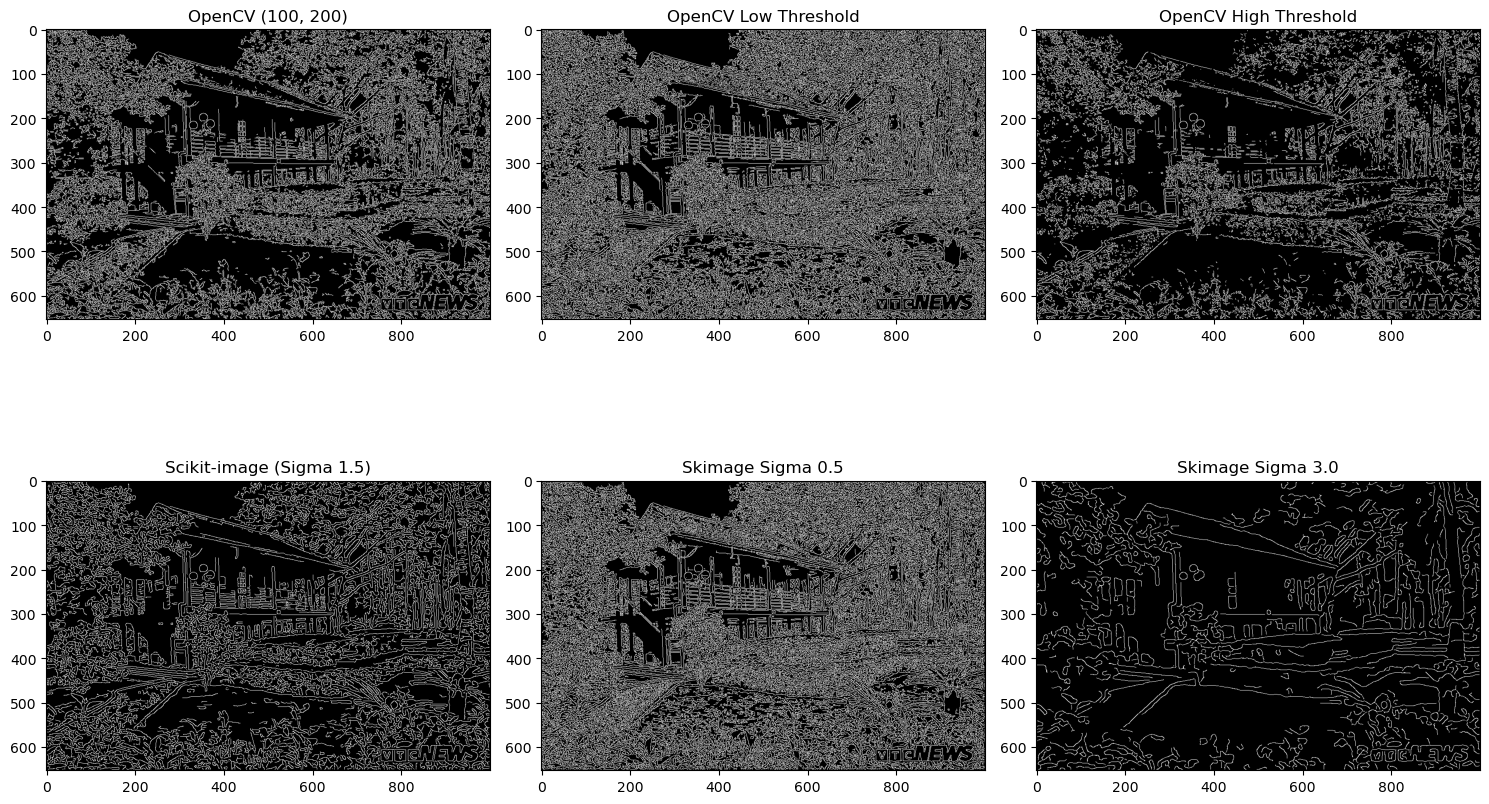

In [7]:
if img_cv is None:
    print("Vui lòng kiểm tra lại đường dẫn ảnh!")
else:
    # --- PHẦN 1: THỰC HIỆN BẰNG CÁC THƯ VIỆN ---
    
    # OpenCV: cv2.Canny(image, low_threshold, high_threshold) [cite: 787]
    edges_cv = cv2.Canny(img_cv, 100, 200)

    # Scikit-image: feature.canny(image, sigma) [cite: 788]
    edges_sk = feature.canny(img_sk, sigma=1.5)

    # --- PHẦN 2: THAY ĐỔI THAM SỐ (Sigma, Ngưỡng) [cite: 790, 794] ---
    
    # Thay đổi ngưỡng trong OpenCV
    edges_low = cv2.Canny(img_cv, 30, 100)   # Ngưỡng thấp: lấy nhiều chi tiết/nhiễu hơn
    edges_high = cv2.Canny(img_cv, 180, 250) # Ngưỡng cao: chỉ lấy các cạnh rất mạnh

    # Thay đổi Sigma trong Scikit-image
    edges_sigma_low = feature.canny(img_sk, sigma=0.5) # Sigma nhỏ: ít mờ, nhiều chi tiết
    edges_sigma_high = feature.canny(img_sk, sigma=3.0) # Sigma lớn: mờ nhiều, lọc nhiễu mạnh

    # --- HIỂN THỊ KẾT QUẢ ---
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 3, 1), plt.imshow(edges_cv, cmap='gray'), plt.title('OpenCV (100, 200)')
    plt.subplot(2, 3, 2), plt.imshow(edges_low, cmap='gray'), plt.title('OpenCV Low Threshold')
    plt.subplot(2, 3, 3), plt.imshow(edges_high, cmap='gray'), plt.title('OpenCV High Threshold')
    
    plt.subplot(2, 3, 4), plt.imshow(edges_sk, cmap='gray'), plt.title('Scikit-image (Sigma 1.5)')
    plt.subplot(2, 3, 5), plt.imshow(edges_sigma_low, cmap='gray'), plt.title('Skimage Sigma 0.5')
    plt.subplot(2, 3, 6), plt.imshow(edges_sigma_high, cmap='gray'), plt.title('Skimage Sigma 3.0')

    plt.tight_layout()
    plt.show()